First Five Records
   CustomerID Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1   Male   24                  21                       9
1           2   Male   20                  25                      28
2           3   Male   18                  20                      11
3           4   Male   19                  24                      24
4           5   Male   18                  25                      22

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values
C

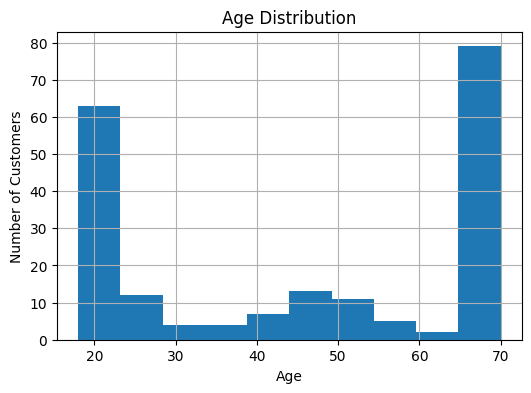

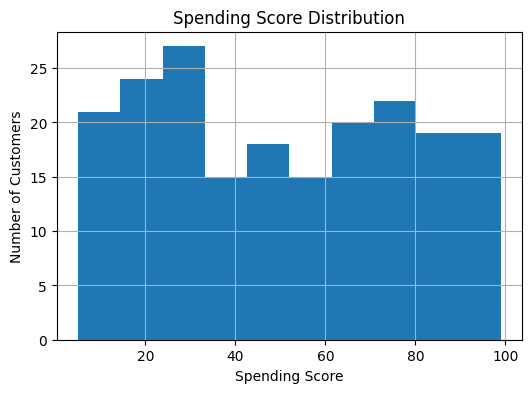

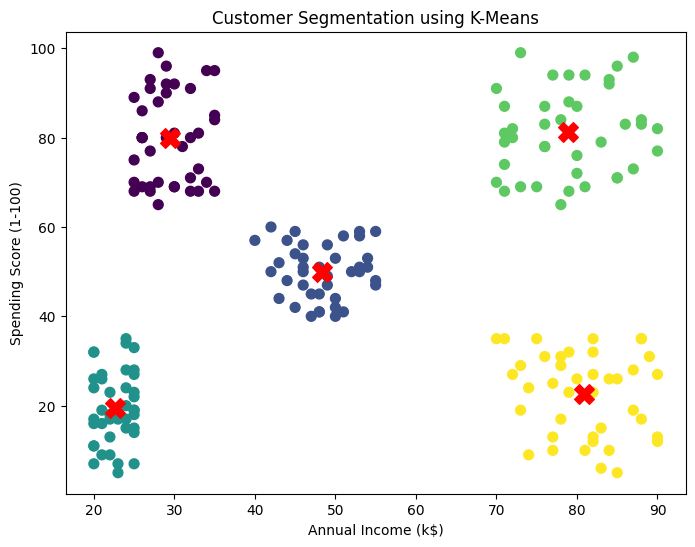

In [8]:
# CUSTOMER SEGMENTATION

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Load the dataset
data = pd.read_csv("Customers1.csv")

print("First Five Records")
print(data.head())

print("\nDataset Information")
print(data.info())

print("\nMissing Values")
print(data.isnull().sum())

# Histogram1

plt.figure(figsize=(6,4))
plt.hist(data["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.grid(True)
plt.show()

# Histogram2

plt.figure(figsize=(6,4))
plt.hist(data["Spending Score (1-100)"], bins=10)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.grid(True)
plt.show()

#Feature selection

X = data[["Annual Income (k$)", "Spending Score (1-100)"]]
kmeans = KMeans(n_clusters=5, random_state=42)
data["Cluster"] = kmeans.fit_predict(X)

# Scatter Plot

plt.figure(figsize=(8,6))
plt.scatter(
    data["Annual Income (k$)"],
    data["Spending Score (1-100)"],
    c=data["Cluster"],
    s=50
)
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    marker="X",
    s=200,
    c="red"
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()

# Step 11: Saving the segmented data

data.to_csv("Customer_Segments.csv", index=False)